### 11. Implementing Convolution
- Objective to implement convolution and associated operations from scratch

In [3]:
import numpy as np

rndGen = np.random.default_rng()

X = rndGen.uniform(low=0.0, high=255.0, size=(128, 128)) #Image size of 128,128

In [4]:
def heInitialization(kernel):
    fanIn = kernel.shape[0] * kernel.shape[1]
    std = np.sqrt(2 / fanIn)
    return np.random.normal(0, std, kernel.shape)

In [5]:
def batchNorm(inputImage, gamma=1.0, beta=0.0, epsilon=1e-5):

    mean = np.mean(inputImage)
    variance = np.var(inputImage)

    normalizedImage = (inputImage - mean) / np.sqrt(variance + epsilon) #standardization

    outputImage = gamma * normalizedImage + beta

    return outputImage

In [6]:
def ReLU(inputImage):
    return np.maximum(0, inputImage)

In [7]:
def convolutionForward(inputImage, kernel, stride): # Same padding, O = Floor((N+2P-K)/S) + 1

    inputHeight, inputWidth = inputImage.shape
    kernelHeight, kernelWidth = kernel.shape

    outputHeight = ((inputHeight - kernelHeight) // stride) + 1
    outputWidth = ((inputWidth - kernelWidth) // stride) + 1

    outputImage = np.zeros((outputHeight, outputWidth))

    for row in range(outputHeight):
        for col in range(outputWidth):

            startRow = row * stride
            startCol = col * stride

            currentRegion = inputImage[
                startRow:startRow + kernelHeight,
                startCol:startCol + kernelWidth
            ]

            outputImage[row, col] = np.sum(currentRegion * kernel)

    return outputImage

In [9]:
k = np.zeros((3,3)) #3*3 Kernel
s = 2 #Stride 2

In [27]:
# Convolution
k = heInitialization(k) #In real life, He is initializing just by using the dimensions, we dont have to initialize zeros and pass k 

z = convolutionForward(X,k,s)

y = ReLU(z)

yOut = batchNorm(y)

In [28]:
print(y)

[[ 45.48572141  64.6940596   82.51651336 ... 324.26685875 332.78336163
  272.71923562]
 [123.97278296 121.38001361 361.25779186 ...   3.87765726 231.22485786
   88.60522168]
 [201.90753674 207.04898338 179.46697331 ... 248.30311684 248.14536139
  240.60467415]
 ...
 [ 65.00607243  80.15913444 211.21762643 ...   0.         156.22437995
    2.81509452]
 [102.04651033 251.81489808 453.68114156 ... 344.36616218 307.07931114
  209.30391969]
 [ 90.49291518 169.85972353 130.22280388 ... 315.20906352 197.1811448
  270.259978  ]]


In [29]:
X.shape

(128, 128)

In [30]:
yOut.shape

(63, 63)

Just for fun, visualizing the input and output

In [31]:
import matplotlib.pyplot as plt

def displayImage(image, title):
    plt.figure(figsize=(3, 3))
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

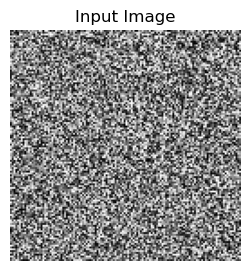

In [32]:
displayImage(X, "Input Image")

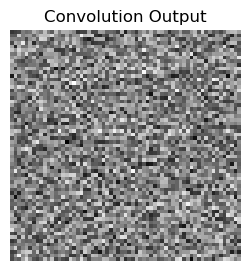

In [33]:
displayImage(z, "Convolution Output")

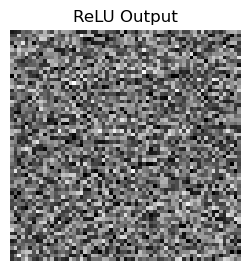

In [34]:
displayImage(y, "ReLU Output")

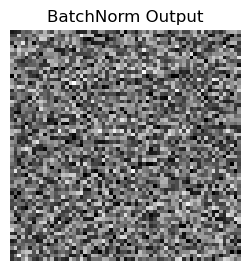

In [35]:
displayImage(yOut, "BatchNorm Output")